## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





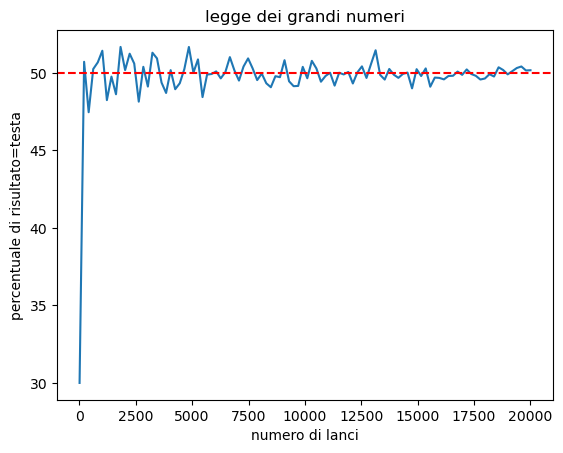

In [23]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

def simula(n):
    value = 0
    for i in range(n):
        value += rd.randint(0,1)
    return value/n * 100

def simulazione(N):
    simulazioni = np.linspace(10, 20000, 100, dtype=int)
    #simulazioni = np.array([n for n in range(10,20001, int(20000/100))])
    frequenze = np.array([simula(i) for i in simulazioni])
    plt.plot(simulazioni, frequenze)
    plt.xlabel("numero di lanci")
    plt.ylabel("percentuale di risultato=testa")
    plt.title("legge dei grandi numeri")
    plt.axhline(50, color='red', linestyle='--')

simulazione(5)



## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [119]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#colonne
df.count(axis=1).max()
#righe
df.count(axis=0).max()

list_of_nan = df.isna().sum()

moda_embarked = df['Embarked'].mode()[0]

df['Embarked'] = df['Embarked'].fillna(moda_embarked)

df[df.duplicated(keep=False)]

df['Age'] = df['Age'].fillna(df['Age'].mean())
df.groupby('Pclass')['Age'].mean()

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


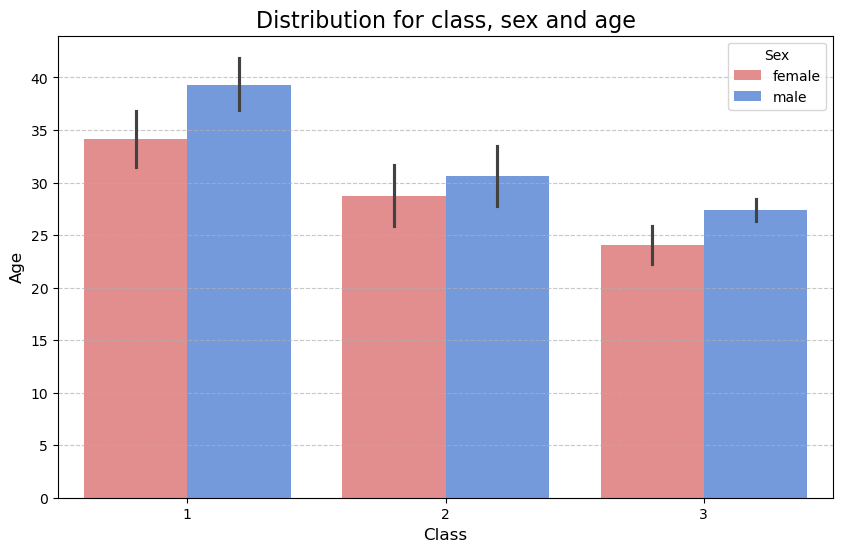

In [121]:
# 2. Creiamo il grafico a barre affiancate
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df, 
    x='Pclass', 
    y='Age', 
    hue='Sex', 
    palette={'male': 'cornflowerblue', 'female': 'lightcoral'}
)

# 3. Personalizziamo il layout
plt.title('Distribution for class, sex and age', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostriamo il grafico
plt.show()


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df['species'].value_counts()

df.groupby('species')[['petal_width', 'petal_length']].mean()

df.groupby('species')[['petal_width', 'petal_length']].mean()

,petal_width,petal_length
species,,
setosa,0.246,1.462
versicolor,1.326,4.260
virginica,2.026,5.552


Text(0.5, 1.0, 'Scatter Plot Avanzato con Seaborn')

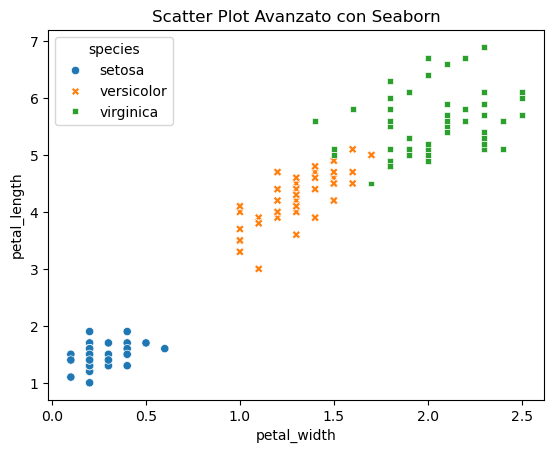

In [144]:
sns.scatterplot(data=df, x='petal_width', y='petal_length', hue='species', style='species')
plt.title('Scatter Plot Avanzato con Seaborn')

<Axes: xlabel='Area', ylabel='species'>

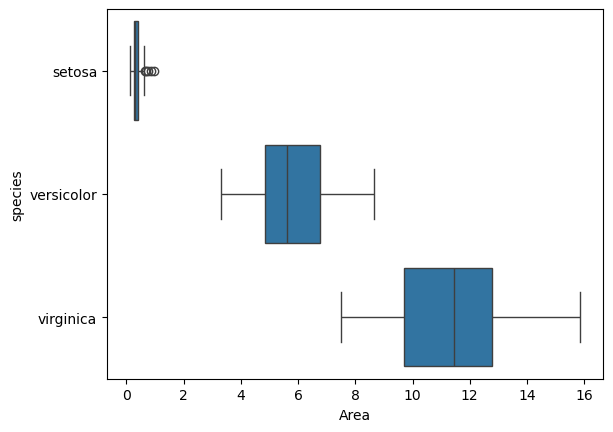

In [151]:
df['Area'] = df['petal_width']*df['petal_length']
sns.boxplot(data=df, x='Area', y='species')